# Sentinela Verde — caracterização territorial de data centers nas Américas

**612 campi. Brasil e Estados Unidos. Nenhuma afirmação causal.**

Este notebook responde três perguntas que não precisam de data de obra:

1. **Em que terreno** data centers se instalam?
2. **O que há ao redor** deles hoje?
3. **São mais quentes** que a região em que estão?

---

### Por que este estudo existe ao lado do causal

O estudo causal desta frente (notebook 02) mede **22 pares** com controle pareado,
tendências pré-obra verificadas e placebo. Ele responde *"o data center causou?"* — e para
isso precisa saber **quando** a obra começou, porque sem o período de antes não há
comparação.

A data existe para 26 campi. Não existe para 612.

Em vez de inventar as datas que faltam — o que transformaria o resultado numa propriedade
do método de imputação, não do território — este notebook faz a pergunta que os 612 campi
**podem** responder. É menos ambicioso e inteiramente medido.

Os dois se complementam: o descritivo dá escala, o causal dá profundidade.

In [1]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
d = pd.read_csv(RAIZ / "dados-modelo-impacto" / "raw" / "controles-rf" / "descritivo_campi.csv")
ok = d[d.lst_campus.notna()].copy()
print(f"{len(d)} campi na lista · {len(ok)} com medição de satélite completa")
print(d.pais.value_counts().to_string())

612 campi na lista · 612 com medição de satélite completa
pais
US    488
BR    124


## ⚠ A ressalva que acompanha toda comparação Brasil × EUA

As duas metades vêm de **fontes diferentes**, e não por escolha:

| | Brasil | EUA |
|---|---:|---:|
| OpenStreetMap | **45** elementos | **1.649** elementos |
| datacentermap | 242 registros | bloqueado (anti-bot) |

O OSM mal cobre o Brasil; o datacentermap não é raspável para os EUA sem Selenium e
dezenas de horas. Cada país entrou pela melhor fonte **dele**.

**Consequência:** diferença medida entre BR e EUA pode ser diferença de **cobertura de
cadastro**, não de território. Onde o número aparecer comparado entre países, isso vale.
Onde for descrição dentro de um país, não se aplica.

## 1. Onde eles estão

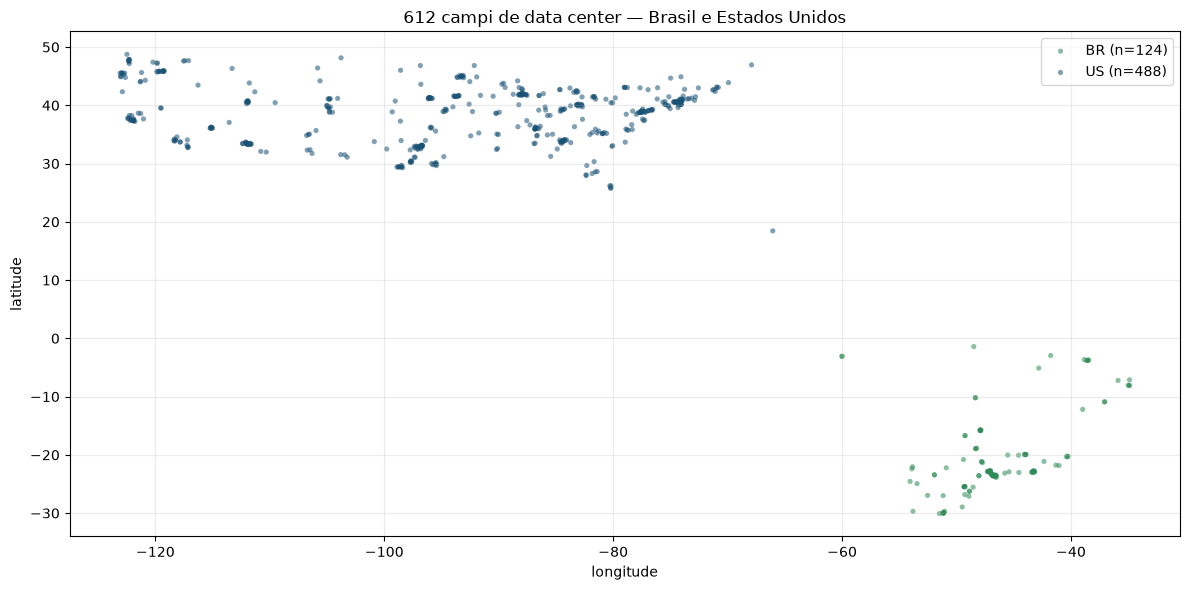

In [2]:
fig, ax = plt.subplots(figsize=(12, 6))
cores = {"BR": "#2E8B57", "US": "#1A5276"}
for pais, g in d.groupby("pais"):
    ax.scatter(g.lon, g.lat, s=14, alpha=.55, c=cores[pais], label=f"{pais} (n={len(g)})",
               edgecolors="none")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title("612 campi de data center — Brasil e Estados Unidos", fontsize=12)
ax.legend(); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

## 2. Em que terreno se instalam

Cobertura do solo no raio de 1 km — % mediano

      veg_densa  veg_rala  solo_exposto  construida  agua
pais                                                     
BR          6.9       1.3           0.0        85.5   0.0
US          9.4       4.6           0.7        61.8   0.4


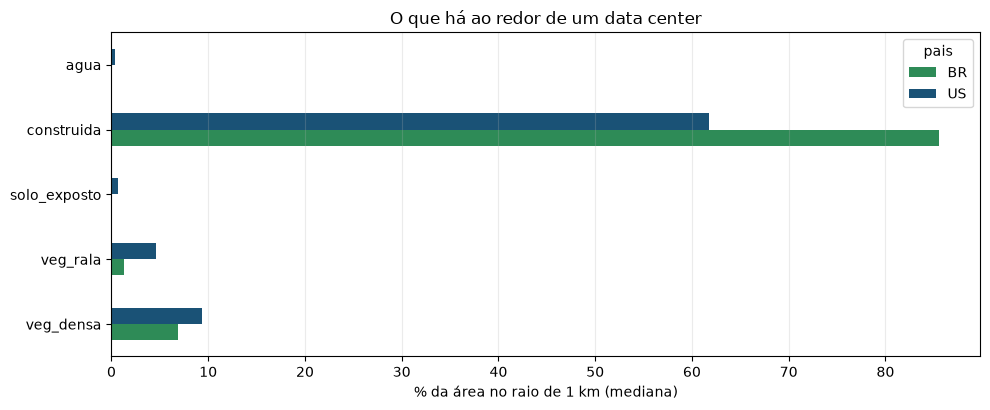

In [3]:
cols = [c for c in ok.columns if c.startswith("pct_")]
med = ok.groupby("pais")[cols].median().round(1)
med.columns = [c.replace("pct_", "") for c in med.columns]
print("Cobertura do solo no raio de 1 km — % mediano\n")
print(med.to_string())

fig, ax = plt.subplots(figsize=(10, 4.2))
med.T.plot(kind="barh", ax=ax, color=[cores[p] for p in med.index])
ax.set_xlabel("% da área no raio de 1 km (mediana)")
ax.set_title("O que há ao redor de um data center", fontsize=12)
ax.grid(axis="x", alpha=.25); plt.tight_layout(); plt.show()

### Terreno livre ou terreno já ocupado

Para os campi americanos com footprint no OpenStreetMap, medimos **quanto da área do
prédio já era construída antes da obra** (Dynamic World). Abaixo de 50% chamamos de
*greenfield* — data center que chegou em terreno livre.

A distinção importa porque um data center dentro de parque industrial existente **não tem
para onde induzir desenvolvimento**: o terreno ao redor já está tomado.

greenfield: 120 de 458 (26%)


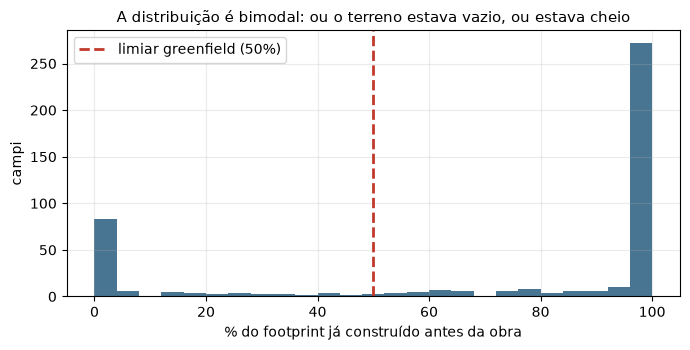

In [4]:
if "greenfield" in ok.columns and ok.greenfield.notna().any():
    g = ok[ok.greenfield.notna()]
    n_gf = int((g.greenfield == True).sum())
    print(f"greenfield: {n_gf} de {len(g)} ({100*n_gf/len(g):.0f}%)")
    fig, ax = plt.subplots(figsize=(7, 3.6))
    ax.hist(g.frac_built_inicio * 100, bins=25, color="#1A5276", alpha=.8)
    ax.axvline(50, color="#C0392B", ls="--", lw=2, label="limiar greenfield (50%)")
    ax.set_xlabel("% do footprint já construído antes da obra")
    ax.set_ylabel("campi"); ax.legend(); ax.grid(alpha=.25)
    ax.set_title("A distribuição é bimodal: ou o terreno estava vazio, ou estava cheio", fontsize=11)
    plt.tight_layout(); plt.show()
else:
    print("sem classificação greenfield disponível")

## 3. São mais quentes que a região?

Esta é a pergunta da ilha de calor, feita de um jeito que **não precisa de data de obra**.

Em vez de *"esquentou depois que construíram?"* — que exige antes e depois, e trava em
n=12 — perguntamos:

> **A temperatura de superfície no entorno imediato do data center (1 km) é maior que a da
> região em volta dele (anel de 5–10 km), hoje?**

É contraste **espacial**, não temporal. Roda com N=612.

**O que isso não separa, e precisa estar dito:** não distingue *"o data center aqueceu o
entorno"* de *"data centers se instalam em lugares que já eram mais quentes"* — perto de
rodovia, em área industrial, longe de vegetação. Para isso serve o estudo causal.

Anomalia térmica — campus (1 km) menos região (anel 5–10 km)

  BR: n= 124   mediana +2.16 °C   ·  82% mais quentes que sua região
  US: n= 488   mediana +1.59 °C   ·  80% mais quentes que sua região

  TOTAL: n=612   mediana +1.67 °C


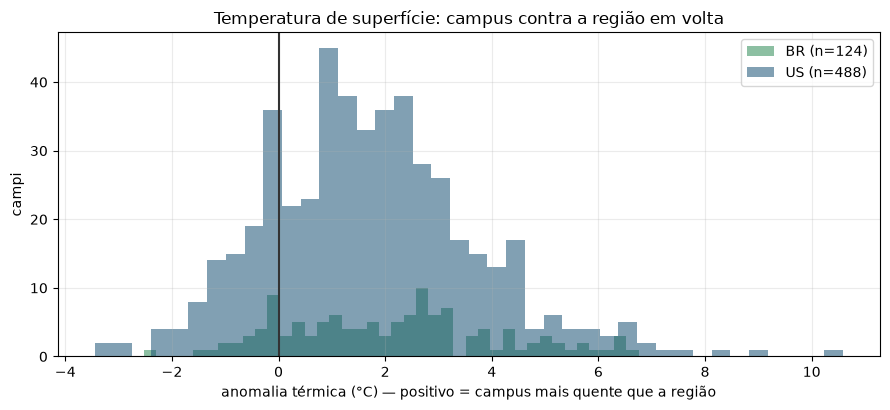

In [5]:
a = ok[ok.anomalia_termica_c.notna()]
print("Anomalia térmica — campus (1 km) menos região (anel 5–10 km)\n")
for pais, g in a.groupby("pais"):
    pos = 100 * (g.anomalia_termica_c > 0).mean()
    print(f"  {pais}: n={len(g):>4}   mediana {g.anomalia_termica_c.median():+.2f} °C"
          f"   ·  {pos:.0f}% mais quentes que sua região")
print(f"\n  TOTAL: n={len(a)}   mediana {a.anomalia_termica_c.median():+.2f} °C")

fig, ax = plt.subplots(figsize=(9, 4.2))
for pais, g in a.groupby("pais"):
    ax.hist(g.anomalia_termica_c, bins=40, alpha=.55, label=f"{pais} (n={len(g)})",
            color=cores[pais])
ax.axvline(0, color="#333", lw=1.5)
ax.set_xlabel("anomalia térmica (°C) — positivo = campus mais quente que a região")
ax.set_ylabel("campi"); ax.legend(); ax.grid(alpha=.25)
ax.set_title("Temperatura de superfície: campus contra a região em volta", fontsize=12)
plt.tight_layout(); plt.show()

### O cruzamento que dá pista causal

Se a anomalia térmica fosse só **seleção de sítio** — data centers escolhidos em lugares já
quentes — ela não deveria diferir entre greenfield e brownfield.

Se **greenfield aquece mais**, isso aponta para conversão de terreno: chegou em terreno
vegetado, substituiu por superfície impermeável, e aqueceu.

Continua não sendo prova causal. Mas é uma pista **medida**, e aponta numa direção
testável.

In [6]:
if "greenfield" in a.columns and a.greenfield.notna().any():
    g = a[a.greenfield.notna()]
    linhas = []
    for gf, sub in g.groupby("greenfield"):
        linhas.append({"terreno": "greenfield" if gf else "brownfield", "n": len(sub),
                       "anomalia_mediana_c": round(sub.anomalia_termica_c.median(), 2),
                       "pct_mais_quente": round(100 * (sub.anomalia_termica_c > 0).mean())})
    print(pd.DataFrame(linhas).to_string(index=False))
else:
    print("sem cruzamento greenfield disponível")

   terreno   n  anomalia_mediana_c  pct_mais_quente
brownfield 338                1.85               80
greenfield 120                1.11               77


## O que este notebook afirma, e o que não

**Afirma** — e cada número é medido sobre os 612 campi:

- em que composição de cobertura data centers se instalam, nos dois países;
- que fração deles chega em terreno livre contra terreno já ocupado;
- se o entorno imediato é termicamente diferente da região em volta.

**Não afirma:**

- que o data center **causou** qualquer uma dessas diferenças. Contraste espacial não
  separa efeito de seleção de sítio;
- que Brasil e EUA diferem **no território** — a diferença de fonte de cadastro é um
  confundidor não controlado;
- nada sobre consumo de água ou energia. Água é encanada e invisível em satélite; energia
  só existe onde o cadastro publica.

**Para a afirmação causal, ver o notebook 02** — 22 pares, controle pareado, tendências
pré-obra verificadas, placebo, e três testes de robustez, um dos quais o achado não passa.